noise addition

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

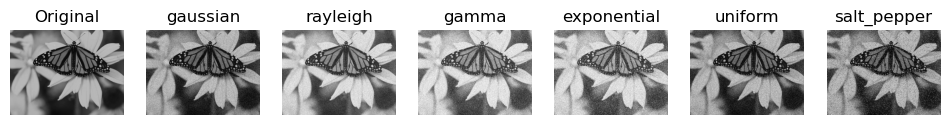

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def add_noise(img, noise_type):
    h, w = img.shape
    noise = np.zeros_like(img, dtype=np.float32)
    
    if noise_type == "gaussian":
        noise = np.random.normal(0, 25, (h, w))
    elif noise_type == "rayleigh":
        noise = np.random.rayleigh(30, (h, w))
    elif noise_type == "gamma":
        noise = np.random.gamma(2.0, 25.0, (h, w))
    elif noise_type == "exponential":
        noise = np.random.exponential(50, (h, w))
    elif noise_type == "uniform":
        noise = np.random.uniform(-50, 50, (h, w))
    elif noise_type == "salt_pepper":
        sp_img = img.copy()
        salt_mask = np.random.rand(h, w) < 0.05
        pepper_mask = np.random.rand(h, w) < 0.05
        sp_img[salt_mask] = 255
        sp_img[pepper_mask] = 0
        return sp_img.astype(np.uint8)

    return np.clip(img + noise, 0, 255).astype(np.uint8)

def display_images(images, titles):
    plt.figure(figsize=(12, 4))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(title)
        plt.axis("off")
    plt.show()

# Load grayscale image
gray_img = cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE)

# Apply noise types
noise_types = ["gaussian", "rayleigh", "gamma", "exponential", "uniform", "salt_pepper"]
noisy_images = [add_noise(gray_img, n) for n in noise_types]

# Display images
display_images([gray_img] + noisy_images, ["Original"] + noise_types)


image restoration

mean filters

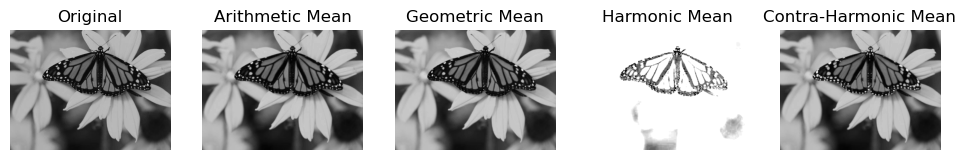

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image in grayscale
gray_img = cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE)

# Arithmetic Mean Filter (Simple Averaging)
def arithmetic_mean(img, ksize=3):
    return cv2.blur(img, (ksize, ksize))

# Geometric Mean Filter (Multiplication-Based Averaging)
def geometric_mean(img, ksize=3):
    img = img.astype(np.float32) + 1e-5  # Avoid zero values
    log_img = np.log(img)
    filtered = cv2.boxFilter(log_img, -1, (ksize, ksize))  # Compute mean in log space
    return np.exp(filtered).astype(np.uint8)

# Harmonic Mean Filter (Inverse Averaging)
def harmonic_mean(img, ksize=3):
    img = img.astype(np.float32) + 1e-5  # Avoid division by zero
    inv_img = 1.0 / img
    filtered = ksize * ksize / cv2.boxFilter(inv_img, -1, (ksize, ksize))
    return np.clip(filtered, 0, 255).astype(np.uint8)

# Contra-Harmonic Mean Filter (Reduces Salt & Pepper Noise)
def contra_harmonic_mean(img, ksize=3, Q=1.5):
    img = img.astype(np.float32) + 1e-5
    num = cv2.boxFilter(img**(Q + 1), -1, (ksize, ksize))
    denom = cv2.boxFilter(img**Q, -1, (ksize, ksize))
    return np.clip(num / (denom + 1e-5), 0, 255).astype(np.uint8)

# Apply filters
filtered_images = {
    "Original": gray_img,
    "Arithmetic Mean": arithmetic_mean(gray_img),
    "Geometric Mean": geometric_mean(gray_img),
    "Harmonic Mean": harmonic_mean(gray_img),
    "Contra-Harmonic Mean": contra_harmonic_mean(gray_img)
}

# Display images
plt.figure(figsize=(12, 5))
for i, (title, img) in enumerate(filtered_images.items()):
    plt.subplot(1, len(filtered_images), i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
plt.show()


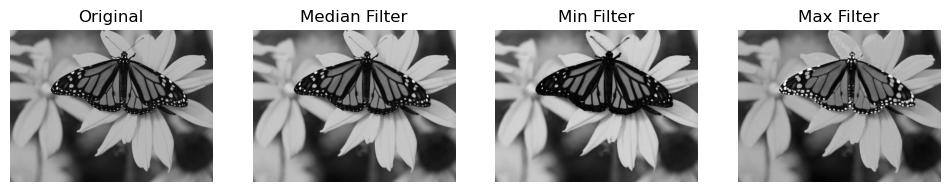

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter, minimum_filter, maximum_filter

# Load the image in grayscale
gray_img = cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE)

# Apply Order Statistical Filters
def apply_filters(img, ksize=3):
    filters = {
        "Original": img,
        "Median Filter": median_filter(img, size=ksize),
        "Min Filter": minimum_filter(img, size=ksize),
        "Max Filter": maximum_filter(img, size=ksize)
    }
    return filters

# Apply filters with a 3x3 kernel
filtered_images = apply_filters(gray_img, ksize=3)

# Display images
plt.figure(figsize=(12, 5))
for i, (title, img) in enumerate(filtered_images.items()):
    plt.subplot(1, len(filtered_images), i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
plt.show()


sobel filter

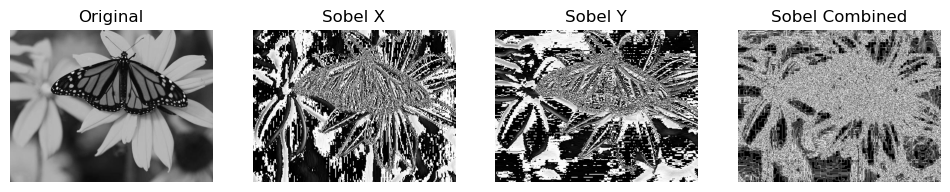

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

# Load image in grayscale
gray_img = cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE)

# Define Sobel kernels
sobel_x_kernel = np.array([[-1, 0, 1],
                            [-2, 0, 2],
                            [-1, 0, 1]])

sobel_y_kernel = np.array([[-1, -2, -1],
                            [0,  0,  0],
                            [1,  2,  1]])

# Apply Sobel filter using convolution
def apply_sobel(img, kernel_x, kernel_y):
    sobel_x = convolve(img, kernel_x)  # Convolution with X kernel
    sobel_y = convolve(img, kernel_y)  # Convolution with Y kernel
    sobel_combined = np.sqrt(sobel_x**2 + sobel_y**2)  # Combine both gradients
    return {
        "Original": img,
        "Sobel X": np.uint8(np.clip(np.abs(sobel_x), 0, 255)),
        "Sobel Y": np.uint8(np.clip(np.abs(sobel_y), 0, 255)),
        "Sobel Combined": np.uint8(np.clip(sobel_combined, 0, 255))
    }

# Apply the filter
filtered_images = apply_sobel(gray_img, sobel_x_kernel, sobel_y_kernel)

# Display images
plt.figure(figsize=(12, 5))
for i, (title, img) in enumerate(filtered_images.items()):
    plt.subplot(1, len(filtered_images), i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
plt.show()
